<a href="https://colab.research.google.com/github/mehdi-belhamiti/Hierarchical-Risk-Parity-Portfolio-Optimization/blob/main/Hierarchical_Risk_Parity_Python_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import yfinance as yf
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram
import scipy.spatial.distance as ssd

In [27]:
# Sélection de 10 actifs pour le portfolio
tickers = ['SPY', 'TLT', 'GLD', 'VIXY', 'USO', 'VNQ', 'EEM', 'BTC-USD', 'UUP', 'FXY']

# Récupération des données des 5 dernieres années
data = yf.download(tickers, period="5y")['Close']

# calcul des rendements journaliers et en enlevant les valeurs manquantes
returns = data.pct_change(fill_method=None).dropna()

corr_matrix = returns.corr()

#Matrice de distance pour le modèle HRP
#Formule : D = sqrt(0.5 * (1 - Corrélation))
distance_matrix = np.sqrt(np.clip(0.5 * (1 - corr_matrix), 0, 1))

print("\ndim rendements :", returns.shape)

/tmp/ipykernel_5401/3924924123.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, period="5y")['Close']
[*********************100%***********************]  10 of 10 completed


dim rendements : (978, 10)


/tmp/ipykernel_5401/1688338850.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_tsla = yf.download("TSLA", period="5y")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_5401/1688338850.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_btc = yf.download("BTC-USD", period="5y")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_5401/1688338850.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_gld = yf.download("GLD", period="5y")
[*********************100%***********************]  1 of 1 completed


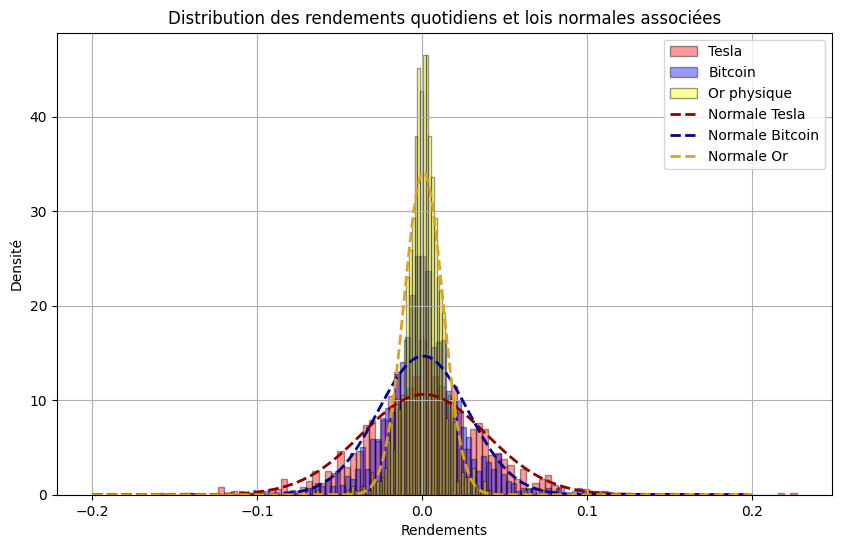

Moyenne empirique rendements quotidiens Tesla : 0.0010148267580943845 Ecart type rendements tesla : 0.03758585439459591
Moyenne empirique rendements quotidiens bitcoin : 0.0005696688408976692 Ecart type rendements bitcoin : 0.027211061250336118
Moyenne empirique rendements quotidiends or physique : 0.0007764924161858951 Ecart type rendements or physique : 0.011699674592035598


In [30]:
data_tsla = yf.download("TSLA", period="5y")
data_btc = yf.download("BTC-USD", period="5y")
data_gld = yf.download("GLD", period="5y")

data_tsla["Return"] = data_tsla["Close"].pct_change()
data_btc["Return"] = data_btc["Close"].pct_change()
data_gld["Return"] = data_gld["Close"].pct_change()

# Calculs rendements moyens quotidiens et ecart type des rendements quotidiens
mu_tsla, std_tsla = data_tsla["Return"].mean(), data_tsla["Return"].std()
mu_btc, std_btc = data_btc["Return"].mean(), data_btc["Return"].std()
mu_gld, std_gld = data_gld["Return"].mean(), data_gld["Return"].std()

plt.figure(figsize=(10,6))

# histogrammes
plt.hist(data_tsla["Return"].dropna(), bins=100, density=True, alpha=0.4, color="red", edgecolor="black", label="Tesla")
plt.hist(data_btc["Return"].dropna(), bins=100, density=True, alpha=0.4, color="blue", edgecolor="black", label="Bitcoin")
plt.hist(data_gld["Return"].dropna(), bins=100, density=True, alpha=0.4, color="yellow", edgecolor="black", label="Or physique")

# Plot
x = np.linspace(-0.2, 0.2, 1000)
plt.plot(x, stats.norm.pdf(x, mu_tsla, std_tsla), color="darkred", linewidth=2, linestyle='--', label="Normale Tesla")
plt.plot(x, stats.norm.pdf(x, mu_btc, std_btc), color="darkblue", linewidth=2, linestyle='--', label="Normale Bitcoin")
plt.plot(x, stats.norm.pdf(x, mu_gld, std_gld), color="goldenrod", linewidth=2, linestyle='--', label="Normale Or")

plt.title("Distribution des rendements quotidiens et lois normales associées")
plt.xlabel("Rendements")
plt.ylabel("Densité")
plt.legend()
plt.grid(True)
plt.show()

print("Moyenne empirique rendements quotidiens Tesla :", mu_tsla,"Ecart type rendements tesla :", std_tsla)
print("Moyenne empirique rendements quotidiens bitcoin :", mu_btc,"Ecart type rendements bitcoin :", std_btc)
print("Moyenne empirique rendements quotidiends or physique :", mu_gld,"Ecart type rendements or physique :",std_gld)

[0.5630461  0.69018215 0.65609357 0.52568594 0.71266084 0.69013254
 0.77691398 0.82838863 0.59864829 0.65065724 0.55552233 0.39821359
 0.67007156 0.69950172 0.85666359 0.88205896 0.53863277 0.56393418
 0.70810825 0.57314377 0.7233521  0.9091506  0.67109898 0.64789104
 0.6439114  0.61743921 0.67723797 0.85240537 0.73244356 0.64115149
 0.67539596 0.67759972 0.80078125 0.94152296 0.40961197 0.76134762
 0.7960585  0.71512343 0.59738079 0.70940378 0.72128282 0.69504463
 0.64656094 0.81577025 0.87108065]


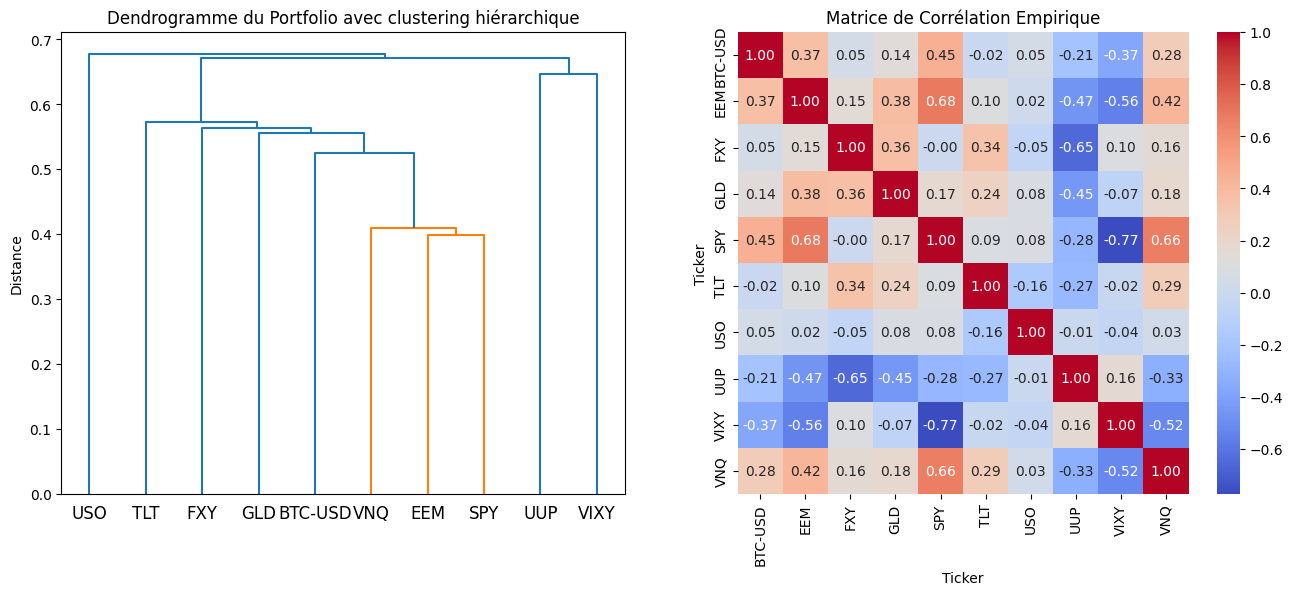

In [31]:
condensed_dist = ssd.squareform(distance_matrix)
print (condensed_dist)

# Clustering hiérarchique
Z = linkage(condensed_dist, method='single')

# visualisation dendrogramme et heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

dendrogram(Z, labels=distance_matrix.columns, ax=axes[0])
axes[0].set_title("Dendrogramme du Portfolio avec clustering hiérarchique")
axes[0].set_ylabel("Distance")

sns.heatmap(corr_matrix, annot=True,fmt='.2f',cmap='coolwarm',
            xticklabels=corr_matrix.columns, yticklabels=corr_matrix.columns,
            ax=axes[1])
axes[1].set_title("Matrice de Corrélation Empirique")
plt.show()

In [32]:
# matrice de cov
cov_matrix = returns.cov()

# On recupere l'ordre avec le dendrogramme
sort_ix = dendrogram(Z,no_plot = True)['leaves']
sorted_tickers = returns.columns[sort_ix]

print("Ordre des actifs :", sorted_tickers.tolist())

# Fonction pr calculer la variance d'un cluster
def get_cluster_var(cov, c_items):
    # on isole la sous matrice
    cov_ = cov.iloc[c_items, c_items]
    # calcul de l'inverse de la variance
    ivp = 1.0 / np.diag(cov_)
    ivp /= ivp.sum()
    w_ = ivp.reshape(-1, 1)
    # Variance totale w^T * Cov * w
    return np.dot(np.dot(w_.T, cov_), w_)[0, 0]

def get_rec_bipart(cov, sort_ix):
    # on met 100% du poids au debut
    w = pd.Series(1.0, index=sort_ix)
    c_items = [sort_ix]

    while len(c_items) > 0:
        #On coupe chaque cluster en 2
        c_items = [i[j:k] for i in c_items for j, k in ((0, len(i) // 2), (len(i) // 2, len(i))) if len(i) > 1]

        for i in range(0, len(c_items), 2):
            c_1 = c_items[i]
            c_2 = c_items[i + 1]

            # Risque de chaque moitie
            var_1 = get_cluster_var(cov, c_1)
            var_2 = get_cluster_var(cov, c_2)

            # Facteur alpha pourr donner + de poids au moins risqué
            alpha = 1 - var_1 / (var_1 + var_2)

            # maj des poids
            w[c_1] *= alpha
            w[c_2] *= (1 - alpha)

    return w

Ordre des actifs : ['USO', 'TLT', 'FXY', 'GLD', 'BTC-USD', 'VNQ', 'EEM', 'SPY', 'UUP', 'VIXY']


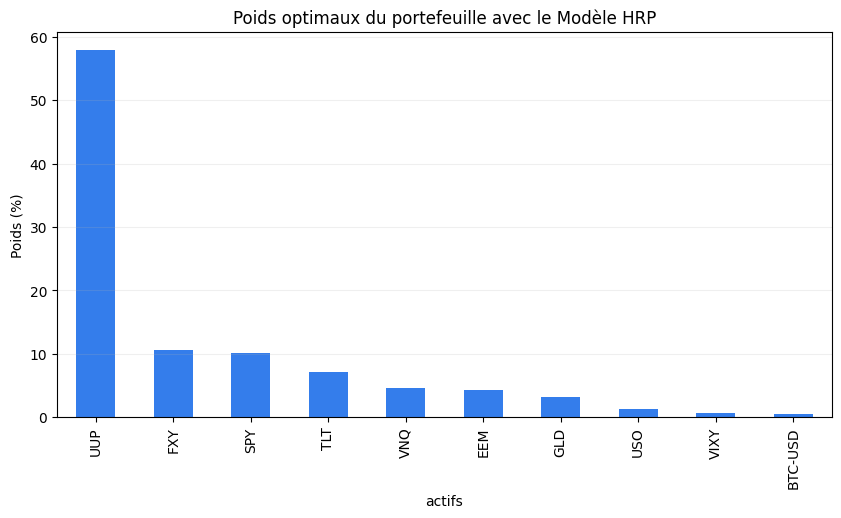


allocation finale :
UUP      : 57.86 %
FXY      : 10.52 %
SPY      : 10.10 %
TLT      : 7.13 %
VNQ      : 4.52 %
EEM      : 4.21 %
GLD      : 3.16 %
USO      : 1.34 %
VIXY     : 0.69 %
BTC-USD  : 0.48 %


In [36]:
# Calcul final des poids
hrp_weights = get_rec_bipart(cov_matrix, sort_ix)

# on remet les vrais tickers pour sy retrouver
hrp_weights.index = corr_matrix.columns[hrp_weights.index]
hrp_weights = hrp_weights * 100
hrp_weights = hrp_weights.sort_values(ascending=False)

#Plot
plt.figure(figsize=(10, 5))
hrp_weights.plot(kind='bar', color='#347deb')
plt.title("Poids optimaux du portefeuille avec le Modèle HRP")
plt.ylabel("Poids (%)")
plt.xlabel("actifs")
plt.grid(axis='y', alpha=0.2)
plt.show()

print("\nallocation finale :")
for ticker, weight in hrp_weights.items():
    print(f"{ticker:8} : {weight:.2f} %")